## CreditWise Loan System

### This Model predicts Loan Approval on the basis of applicant details. 

## Problem Statement

Manual verification process of loan approval by checking income proofs,employment details,credit history,and other documents is time-consuming, biased & inconsistent.

To solve this problem, this intelligent loan approval system is built to analyse applicant details and predict loan approval.  

### Two major challenges :

1. *Good customers sometimes get rejected*, leading to *loss of business*.
2. *High-risk customers sometimes get approved*, leading to *financial losses*. 

## Tech Stack & Tools

* Programming Language : Python
* Libraries : NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn
* Environment : Jupyter Notebook

## Import required libraries

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,r2_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

## Data Loading

In [160]:
df = pd.read_csv("loan_approval_data.csv")

## Initial Data Inspection

In [161]:
df.head()
df.info()
df.isnull().sum() 
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## Data Cleaning & Preprocessing

### Handling missing values

In [162]:
# seperate the numeric and object content columns seperately

# numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns

# categorical columns 
categorical_cols = df.select_dtypes(include=["object"]).columns

In [163]:
# filling the missing values by the use of Imputer

# numerical imputer = to fill with numeric values
num_imp = SimpleImputer(strategy="mean")
df[numeric_cols] = num_imp.fit_transform(df[numeric_cols])

# categorical imputer = to fill the string values 
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [164]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [165]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## EDA - Exploratory Data Analysis 

In [166]:
# how balanced our classes are 

target_count = df["Loan_Approved"].value_counts()
print(target_count)

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


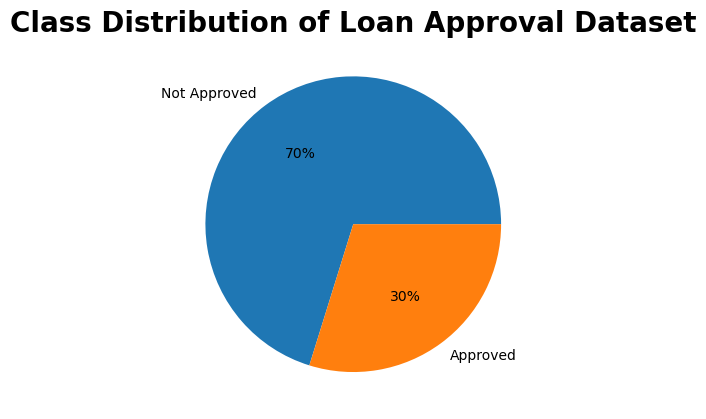

In [167]:
## pie-chart for class distribution 
plt.pie(
    target_count,labels=["Not Approved","Approved"],autopct="%.0f%%"
)
plt.title("Class Distribution of Loan Approval Dataset",fontsize="20",fontweight="bold")
plt.show()

In [168]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [169]:
loan_purp_count = df["Loan_Purpose"].value_counts()
print(loan_purp_count)

Loan_Purpose
Business     252
Car          199
Home         190
Education    181
Personal     178
Name: count, dtype: int64


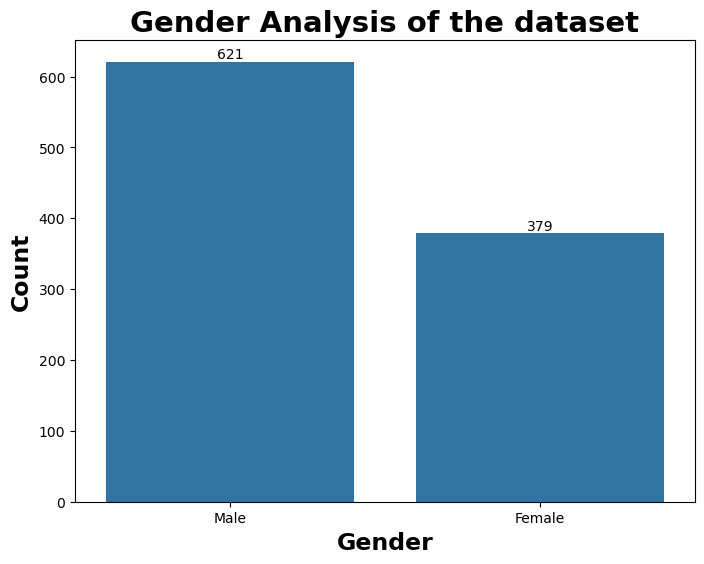

In [170]:
plt.figure(figsize=(8,6))
gender_vals = df["Gender"].value_counts()
ax = sns.barplot(
    gender_vals,
    )
ax.bar_label(ax.containers[0])
plt.title("Gender Analysis of the dataset",fontsize="21",fontweight="bold")
plt.xlabel("Gender",fontsize="17",fontweight="bold")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

In [171]:
# let's analyse the education_level 

ed_level_count = df["Education_Level"].value_counts()
print(ed_level_count)

Education_Level
Graduate        722
Not Graduate    278
Name: count, dtype: int64


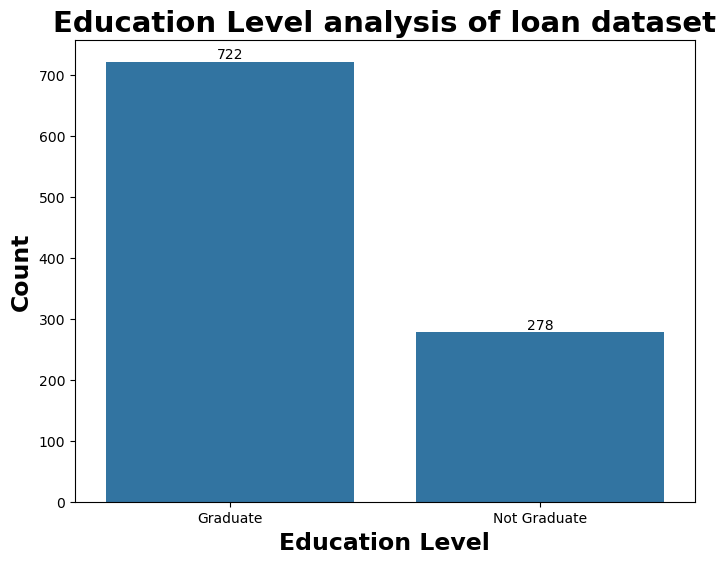

In [172]:
plt.figure(figsize=(8,6))
ax = sns.barplot(
    ed_level_count
)
ax.bar_label(ax.containers[0])
plt.title("Education Level analysis of loan dataset",fontsize="21",fontweight="bold")
plt.xlabel("Education Level",fontsize="17",fontweight="bold")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

In [173]:
emp_sts_count = df["Employment_Status"].value_counts()
print(emp_sts_count)

Employment_Status
Salaried         515
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64


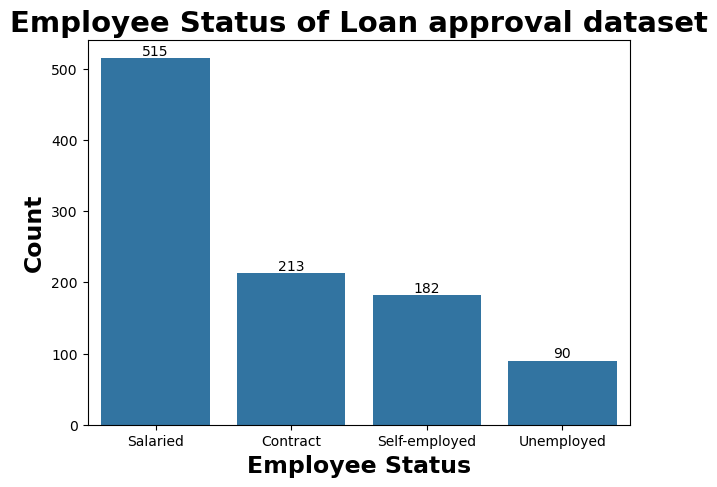

In [174]:
plt.figure(figsize=(7,5))
ax = sns.barplot(
    data = emp_sts_count
    
)
ax.bar_label(ax.containers[0])
plt.title("Employee Status of Loan approval dataset",fontsize="21",fontweight="bold")
plt.xlabel("Employee Status",fontsize="17",fontweight="bold")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

In [175]:
df["Marital_Status"].unique()

array(['Married', 'Single'], dtype=object)

In [176]:
marital_sts_count = df["Marital_Status"].value_counts()
print(marital_sts_count)

Marital_Status
Married    643
Single     357
Name: count, dtype: int64


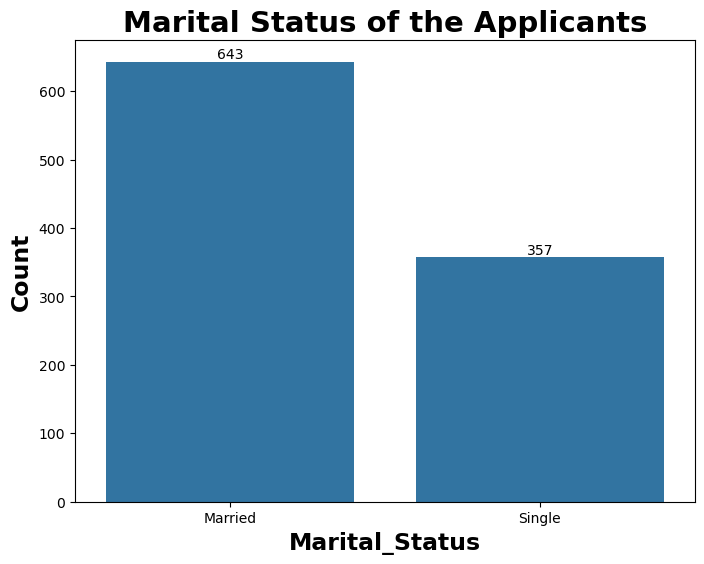

In [177]:
plt.figure(figsize=(8,6))
ax = sns.barplot(
    marital_sts_count
)
ax.bar_label(ax.containers[0])
plt.title("Marital Status of the Applicants",fontsize="21",fontweight="bold")
plt.xlabel("Marital_Status",fontsize="17",fontweight="bold")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

In [178]:
# Loan-Purpose analysis 
loan_purp_count = df["Loan_Purpose"].value_counts()
print(loan_purp_count)

Loan_Purpose
Business     252
Car          199
Home         190
Education    181
Personal     178
Name: count, dtype: int64


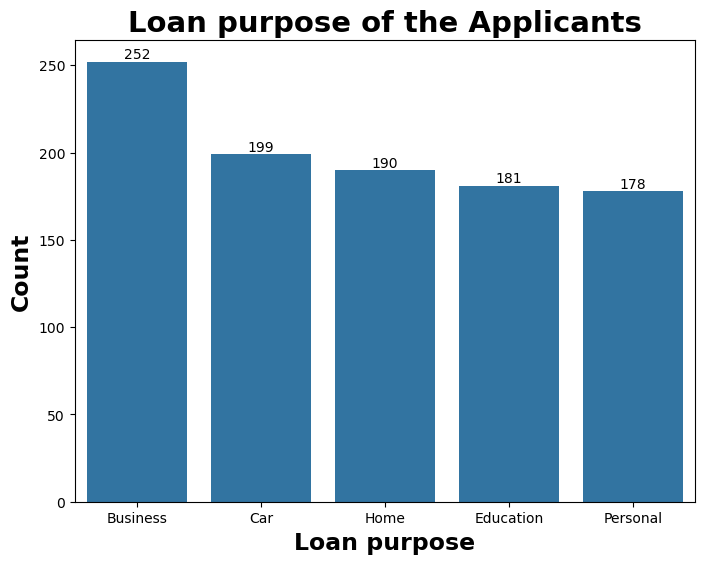

In [179]:
plt.figure(figsize=(8,6))
ax = sns.barplot(
    loan_purp_count
)
ax.bar_label(ax.containers[0])
plt.title("Loan purpose of the Applicants",fontsize="21",fontweight="bold")
plt.xlabel("Loan purpose",fontsize="17",fontweight="bold")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

In [180]:
# property area analysis
prop_area_count = df["Property_Area"].value_counts()
print(prop_area_count)

Property_Area
Urban        517
Rural        294
Semiurban    189
Name: count, dtype: int64


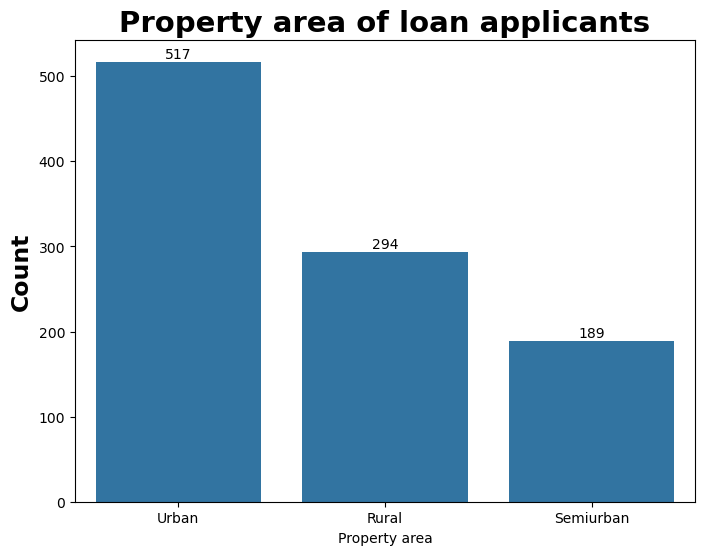

In [181]:
plt.figure(figsize=(8,6))
ax = sns.barplot(
    prop_area_count
)
ax.bar_label(ax.containers[0])
plt.title("Property area of loan applicants",fontsize="21",fontweight="bold")
plt.xlabel("Property area")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

In [182]:
emp_cat_count = df["Employer_Category"].value_counts()
print(emp_cat_count)

Employer_Category
Private       422
Government    202
MNC           144
Business      135
Unemployed     97
Name: count, dtype: int64


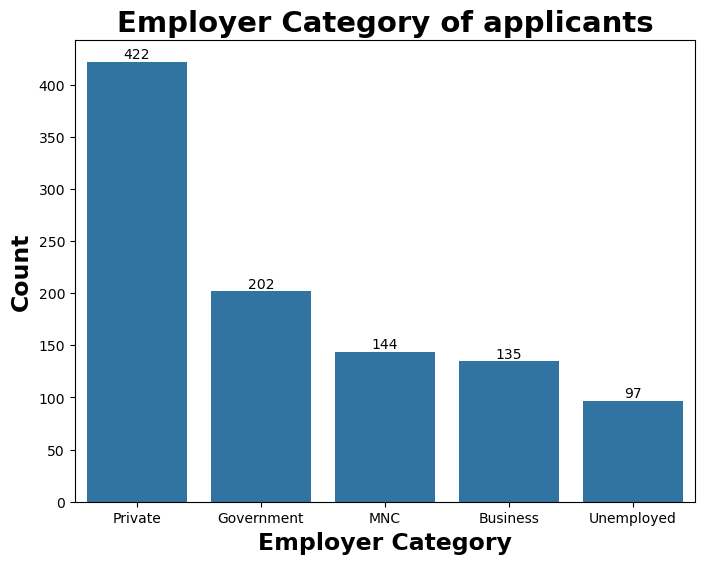

In [183]:
plt.figure(figsize=(8,6))
ax = sns.barplot(
    emp_cat_count
)
ax.bar_label(ax.containers[0])
plt.title("Employer Category of applicants",fontsize="21",fontweight="bold")
plt.xlabel("Employer Category",fontsize="17",fontweight="bold")
plt.ylabel("Count",fontsize="17",fontweight="bold")
plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

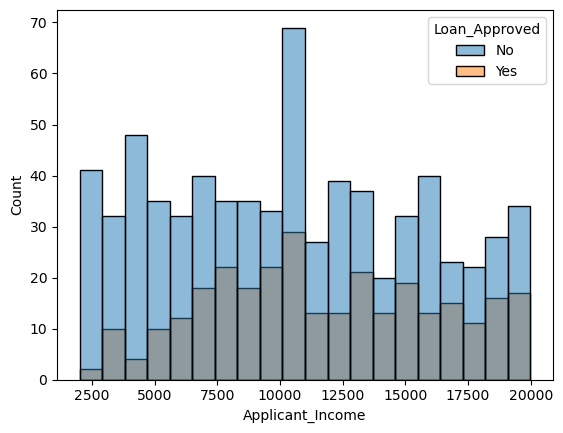

In [184]:
# Based on the applicant income how many of the loans got approved 
sns.histplot(
    data = df,
    x = "Applicant_Income",
    #y = "Loan_Approved",
    bins = 20,
    hue = "Loan_Approved"
)


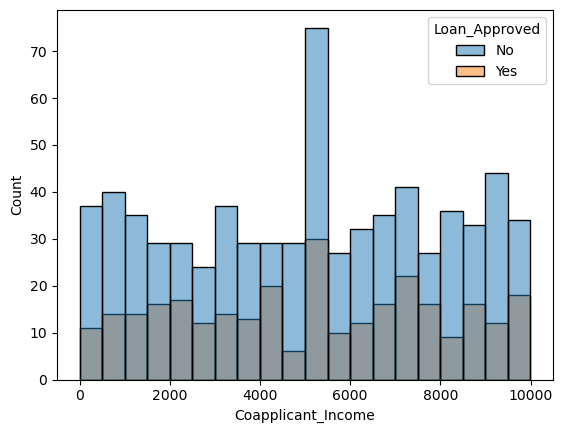

In [185]:
# Based on the applicant income how many of the loans got approved 
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20,
    hue = "Loan_Approved"
)
plt.show()


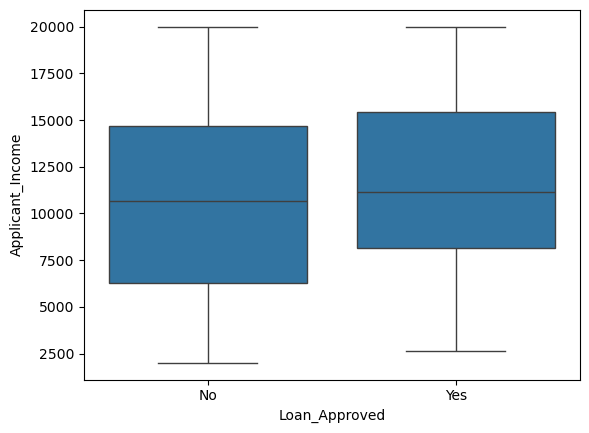

In [186]:
# for outliers detection we use boxplot

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)
plt.show()

In [187]:
numeric_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

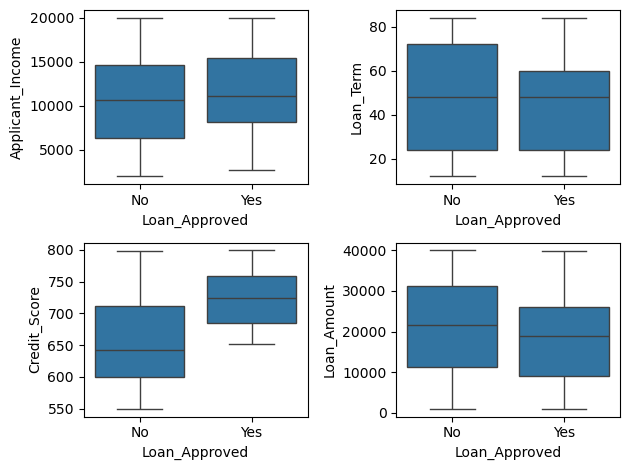

In [188]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Loan_Term")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Loan_Amount")

plt.tight_layout()

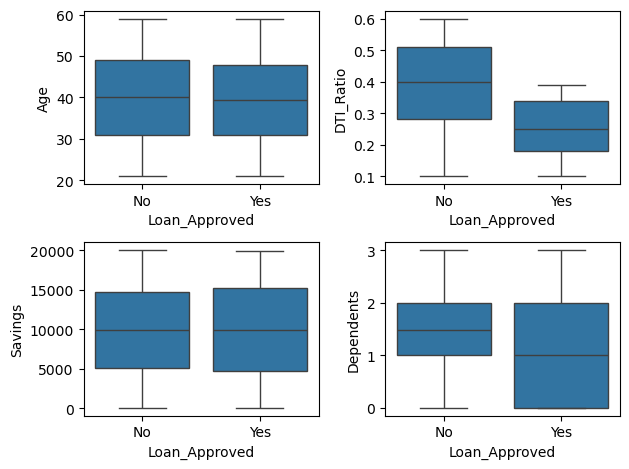

In [189]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Dependents")

plt.tight_layout()

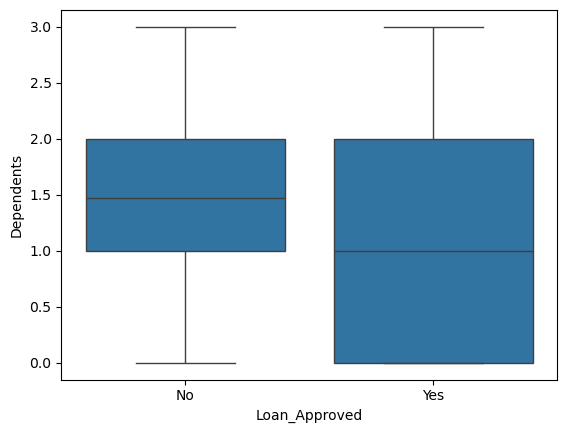

In [190]:
sns.boxplot(data=df,x="Loan_Approved",y="Dependents")
plt.show()

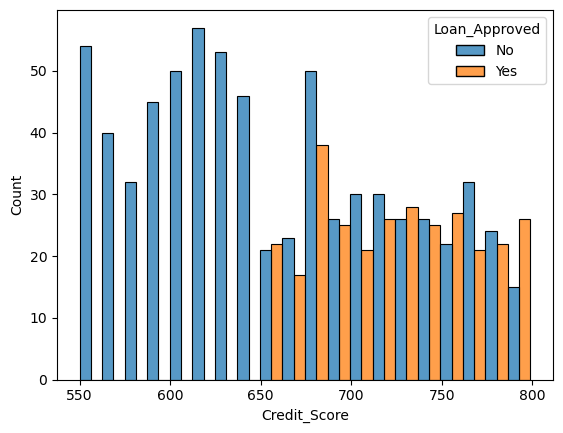

In [191]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    multiple = "dodge",
    bins = 20
)
plt.show()

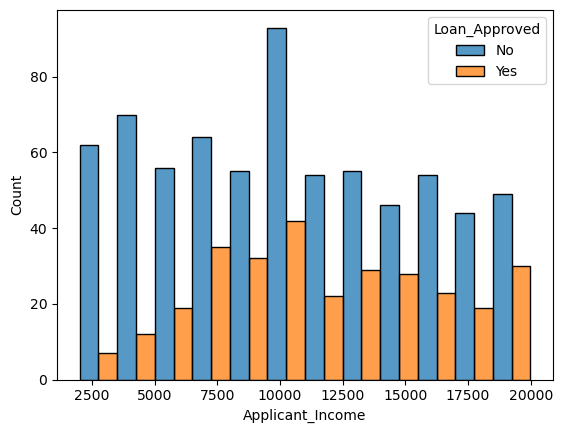

In [192]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    multiple = "dodge"
)
plt.show()

In [193]:
df = df.drop("Applicant_ID",axis=1) # we will remove applicant id 

In [194]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [195]:
df.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## Encoding 

## Encoding Categorical Variables

In [196]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [197]:
# ordinal features
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [198]:
# nominal features
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
ohe_cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area",
            "Gender","Employer_Category"
           ]

encoded = ohe.fit_transform(df[ohe_cols])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(ohe_cols),index=df.index)

df = pd.concat([df.drop(columns=ohe_cols),encoded_df],axis=1)

In [199]:
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [200]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

## Correlation Heatmap

In [201]:
# checks for linear relationships
num_cols = df.select_dtypes(include="number")

corr_matrix = num_cols.corr()

In [202]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

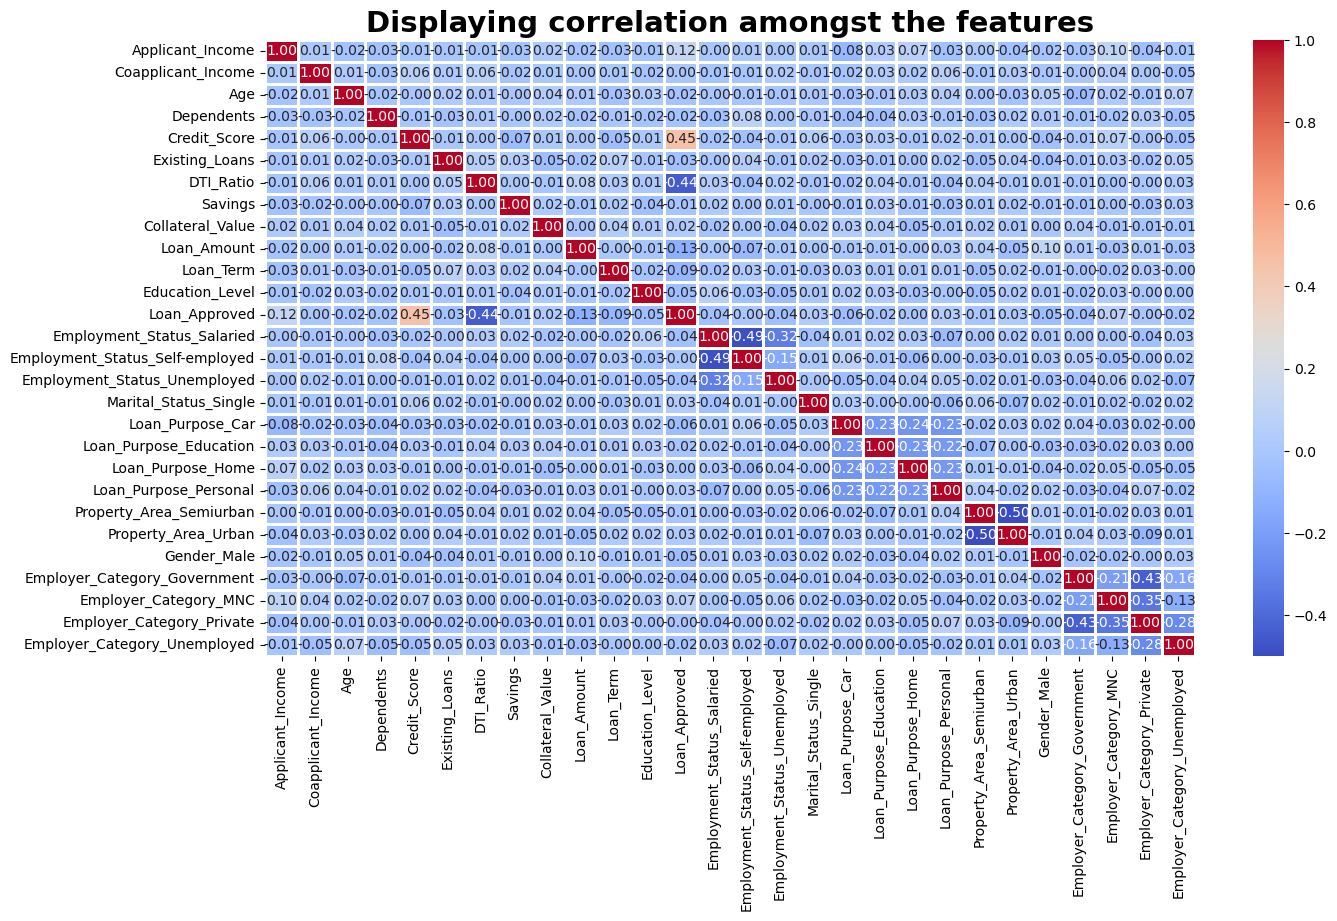

In [217]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidth=1
    
)
plt.title ("Displaying correlation amongst the features",fontsize="21",fontweight="bold")
plt.show()

## Insights

* Credit score has a moderate positive correlation with the loan approval.

* DTI ratio has a moderate negative correlation with the loan approval.

## Feature & Target seperation

In [204]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [205]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [206]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

## Train-Test-Split

In [207]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

X_test.head()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Training Model

### Logistic Regression

In [208]:
Log_model = LogisticRegression()
Log_model.fit(X_train_scaled,y_train)


y_pred = Log_model.predict(X_test_scaled)


prec_scr = precision_score(y_test,y_pred)
recl_scr =recall_score(y_test,y_pred)
f1_scr =f1_score(y_test,y_pred)
acc_scr =accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print("Logistic Regression")
print(f"Precision Score {prec_scr*100:.2f}%")
print(f"Recall Score {recl_scr*100:.2f}%")
print(f"F1 Score {f1_scr*100:.2f}%")
print(f"Accuracy Score {acc_scr*100:.2f}%")
print(cm)


Logistic Regression
Precision Score 78.33%
Recall Score 77.05%
F1 Score 77.69%
Accuracy Score 86.50%
[[126  13]
 [ 14  47]]


### KNN

In [209]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

prec_scr = precision_score(y_test,y_pred)
recl_scr =recall_score(y_test,y_pred)
f1_scr =f1_score(y_test,y_pred)
acc_scr =accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print("KNeighborsClassifier")
print(f"Precision Score {prec_scr*100:.2f}%")
print(f"Recall Score {recl_scr*100:.2f}%")
print(f"F1 Score {f1_scr*100:.2f}%")
print(f"Accuracy Score {acc_scr*100:.2f}%")
print(cm)

KNeighborsClassifier
Precision Score 62.75%
Recall Score 52.46%
F1 Score 57.14%
Accuracy Score 76.00%
[[120  19]
 [ 29  32]]


### Gaussian Naive Bayes

In [210]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

prec_scr = precision_score(y_test,y_pred)
recl_scr =recall_score(y_test,y_pred)
f1_scr =f1_score(y_test,y_pred)
acc_scr =accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print("GaussianNB")
print(f"Precision Score {prec_scr*100:.2f}%")
print(f"Recall Score {recl_scr*100:.2f}%")
print(f"F1 Score {f1_scr*100:.2f}%")
print(f"Accuracy Score {acc_scr*100:.2f}%")
print(cm)

GaussianNB
Precision Score 80.36%
Recall Score 73.77%
F1 Score 76.92%
Accuracy Score 86.50%
[[128  11]
 [ 16  45]]


## Feature Engineering

In [211]:
# to increase the impact of DTI_ratio and Credit_Score we can make this polynomial Features

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

X = df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score"],axis=1)
y = df["Loan_Approved"]

# train-test-split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [212]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


### Logistic Regression after adding polynomial features("DTI_Ratio_sq","Credit_Score_sq")

In [213]:
Log_model = LogisticRegression()
Log_model.fit(X_train_scaled,y_train)

y_pred = Log_model.predict(X_test_scaled)

prec_scr = precision_score(y_test,y_pred)
recl_scr =recall_score(y_test,y_pred)
f1_scr =f1_score(y_test,y_pred)
acc_scr =accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print("Logistic Regression")
print(f"Precision Score {prec_scr*100:.2f}%")
print(f"Recall Score {recl_scr*100:.2f}%")
print(f"F1 Score {f1_scr*100:.2f}%")
print(f"Accuracy Score {acc_scr*100:.2f}%")
print(cm)

Logistic Regression
Precision Score 79.03%
Recall Score 80.33%
F1 Score 79.67%
Accuracy Score 87.50%
[[126  13]
 [ 12  49]]


### KNN after adding polynomial features("DTI_Ratio_sq","Credit_Score_sq")

In [214]:
# KNeighborsClassifier - bcoz classeses were imbalanced and 
#next bcoz of one_hot_encoding the features were numerous, we got sparse data bcoz of which the model did not perform well 
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

prec_scr = precision_score(y_test,y_pred)
recl_scr =recall_score(y_test,y_pred)
f1_scr =f1_score(y_test,y_pred)
acc_scr =accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print("KNeighborsClassifier")
print(f"Precision Score {prec_scr*100:.2f}%")
print(f"Recall Score {recl_scr*100:.2f}%")
print(f"F1 Score {f1_scr*100:.2f}%")
print(f"Accuracy Score {acc_scr*100:.2f}%")
print(cm)

KNeighborsClassifier
Precision Score 62.00%
Recall Score 50.82%
F1 Score 55.86%
Accuracy Score 75.50%
[[120  19]
 [ 30  31]]


### Gaussian Naive Bayes after adding polynomial features("DTI_Ratio_sq","Credit_Score_sq")

In [215]:
# GaussianNaiveBayes = our model for the LoanApproval Systeml
nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

prec_scr = precision_score(y_test,y_pred)
recl_scr =recall_score(y_test,y_pred)
f1_scr =f1_score(y_test,y_pred)
acc_scr =accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print("GaussianNB")
print(f"Precision Score {prec_scr*100:.2f}%")
print(f"Recall Score {recl_scr*100:.2f}%")
print(f"F1 Score {f1_scr*100:.2f}%")
print(f"Accuracy Score {acc_scr*100:.2f}%")
print(cm)

GaussianNB
Precision Score 78.33%
Recall Score 77.05%
F1 Score 77.69%
Accuracy Score 86.50%
[[126  13]
 [ 14  47]]


## 1. NaiveBayes(Precision Score is highest)
## 2. LogisticRegression (The balance b/w precision score and recall score i.e f1_score is highest)

## Conclusion

* **Gaussian Naive Bayes** performs best for the CreditWise Loan System as it has the highest precision score, that means it can very well detect the false positives, i.e, it minimizes the risk of labelling positive a sample that is actually negative.

* Credit_Score and the DTI_Ratio were the most significant features.
